In [42]:
# Step 2: Data Exploration

In [43]:
import pandas as pd

df = pd.read_csv("student-por.csv", delimiter=",", engine="python")
df.columns = df.columns.str.strip()
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [44]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')


In [45]:
# Create protected class groups
df["age_group"] = df["age"].apply(lambda x: 0 if x < 18 else 1)

# Create dependent variables
df["sex"] = df["sex"].map({"M": 0, "F": 1})
df["pass"] = df["G3"].apply(lambda x: 1 if x >= 10 else 0)
df["high_perf"] = df["G3"].apply(lambda x: 1 if x >= 15 else 0)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Dalc,Walc,health,absences,G1,G2,G3,age_group,pass,high_perf
0,GP,1,18,U,GT3,A,4,4,at_home,teacher,...,1,1,3,4,0,11,11,1,1,0
1,GP,1,17,U,GT3,T,1,1,at_home,other,...,1,1,3,2,9,11,11,0,1,0
2,GP,1,15,U,LE3,T,1,1,at_home,other,...,2,3,3,6,12,13,12,0,1,0
3,GP,1,15,U,GT3,T,4,2,health,services,...,1,1,5,0,14,14,14,0,1,0
4,GP,1,16,U,GT3,T,3,3,other,other,...,1,2,5,0,11,13,13,0,1,0


In [46]:
#Protected classes used:
#- Gender (sex): Male (M), Female (F)
#- Age group: Younger (<18), Older (>=18)

#Encoding:
#- Sex: M = 0, F = 1 (conceptually)
#- Age group: Younger = 0, Older = 1

In [47]:
# Frequency Tables
# Gender vs Pass
pd.crosstab(df["sex"], df["pass"])


pass,0,1
sex,,
0,50,216
1,50,333


In [48]:
# Age vs Pass
pd.crosstab(df["age_group"], df["pass"])

pass,0,1
age_group,,
0,62,406
1,38,143


In [49]:
# Gender vs High Performance
pd.crosstab(df["sex"], df["high_perf"])

high_perf,0,1
sex,,
0,223,43
1,295,88


In [50]:
# Age vs High Performance
pd.crosstab(df["age_group"], df["high_perf"])

high_perf,0,1
age_group,,
0,376,92
1,142,39


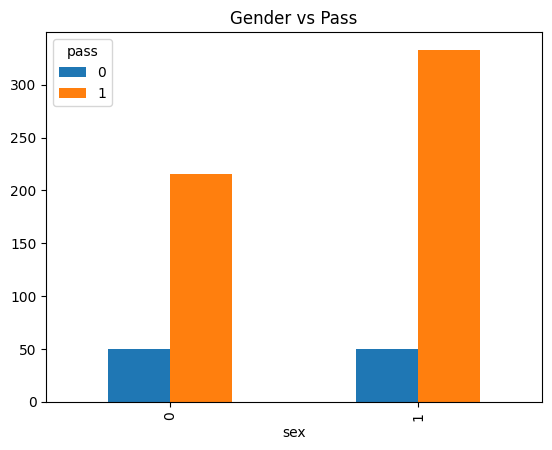

In [51]:
#Graphs
import matplotlib.pyplot as plt

# Gender vs Pass
pd.crosstab(df["sex"], df["pass"]).plot(kind="bar")
plt.title("Gender vs Pass")
plt.show()

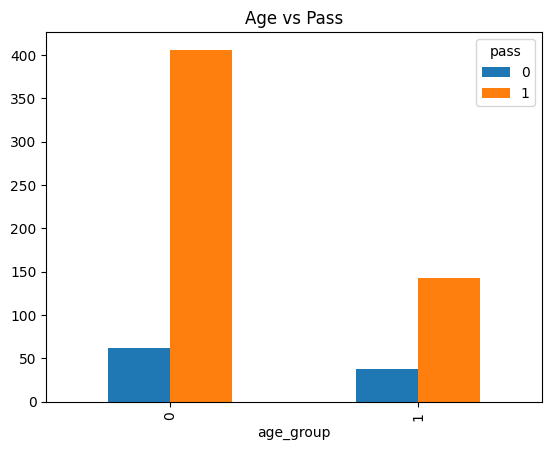

In [52]:

# Age vs Pass
pd.crosstab(df["age_group"], df["pass"]).plot(kind="bar")
plt.title("Age vs Pass")
plt.show()


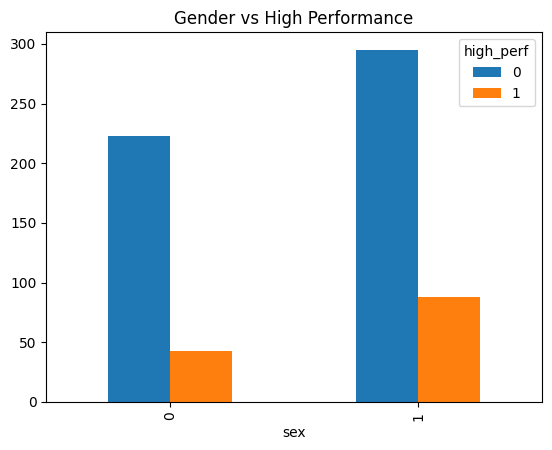

In [53]:
# Gender vs High Performance
pd.crosstab(df["sex"], df["high_perf"]).plot(kind="bar")
plt.title("Gender vs High Performance")
plt.show()

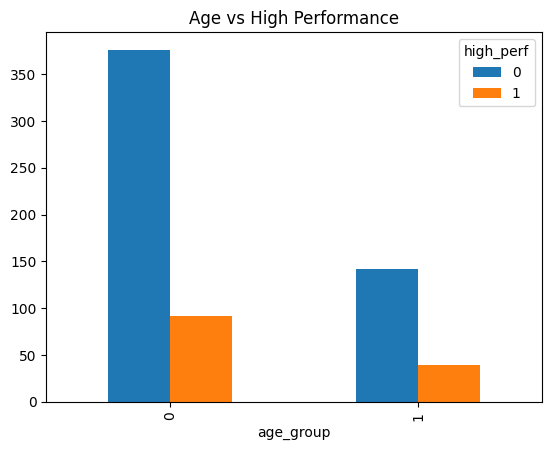

In [54]:

# Age vs High Performance
pd.crosstab(df["age_group"], df["high_perf"]).plot(kind="bar")
plt.title("Age vs High Performance")
plt.show()

In [ ]:
# Step 3: Fairness Metrics and Bias Mitigation
#We use the following fairness metrics:

#Disparate Impact (DI):
#DI = P(Approved | Female) / P(Approved | Male)

#Statistical Parity Difference (SPD):
#SPD = P(Approved | Female) - P(Approved | Male)

#Ideal values:
#- DI ≈ 1 (fair)
#- SPD ≈ 0 (fair)

In [61]:
#compute matrix original data
# gender + pass
male = df[df["sex"] == 0]
female = df[df["sex"] == 1]

p_male = male["pass"].mean()
p_female = female["pass"].mean()

DI = p_female / p_male
SPD = p_female - p_male

print("Gender - Pass")
print("DI:", DI)
print("SPD:", SPD)

Gender - Pass
DI: 1.0707136640557007
SPD: 0.05742162193996747


In [60]:
#gender + high performance
male = df[df["sex"] == 0]
female = df[df["sex"] == 1]

p_male = male["high_perf"].mean()
p_female = female["high_perf"].mean()

DI = p_female / p_male
SPD = p_female - p_male

print("Gender - High Performance")
print("DI:", DI)
print("SPD:", SPD)

Gender - High Performance
DI: 1.4213370575019735
SPD: 0.06811087771648444


In [59]:
#Age + pass
young = df[df["age_group"] == 0]
old = df[df["age_group"] == 1]

p_old = old["pass"].mean()
p_young = young["pass"].mean()

DI = p_young / p_old
SPD = p_young - p_old

print("Age - Pass")
print("DI:", DI)
print("SPD:", SPD)

Age - Pass
DI: 1.0980515211284443
SPD: 0.07746611890258304


In [58]:
#Age + high performance
young = df[df["age_group"] == 0]
old = df[df["age_group"] == 1]

p_old = old["high_perf"].mean()
p_young = young["high_perf"].mean()

DI = p_young / p_old
SPD = p_young - p_old

print("Age - High Performance")
print("DI:", DI)
print("SPD:", SPD)

Age - High Performance
DI: 0.9123383738768354
SPD: -0.018888416678471937


In [63]:
#step 3.3 Bias Mitigation
# Bias Mitigation: Rebalancing dataset based on gender

male = df[df["sex"] == 0]
female = df[df["sex"] == 1]

min_size = min(len(male), len(female))

male_sample = male.sample(min_size, random_state=42)
female_sample = female.sample(min_size, random_state=42)

df_balanced = pd.concat([male_sample, female_sample])

print("Original size:", df.shape)
print("Balanced size:", df_balanced.shape)

Original size: (649, 36)
Balanced size: (532, 36)


In [64]:
#3.4 compute matrix after mitigation
#gender + pass (balanced)
male = df_balanced[df_balanced["sex"] == 0]
female = df_balanced[df_balanced["sex"] == 1]

p_male = male["pass"].mean()
p_female = female["pass"].mean()

DI = p_female / p_male
SPD = p_female - p_male

print("Gender - Pass (Balanced)")
print("DI:", DI)
print("SPD:", SPD)

Gender - Pass (Balanced)
DI: 1.0694444444444446
SPD: 0.0563909774436091


In [65]:
#gender + high performance (balanced)
male = df_balanced[df_balanced["sex"] == 0]
female = df_balanced[df_balanced["sex"] == 1]

p_male = male["high_perf"].mean()
p_female = female["high_perf"].mean()

DI = p_female / p_male
SPD = p_female - p_male

print("Gender - High Performance (Balanced)")
print("DI:", DI)
print("SPD:", SPD)

Gender - High Performance (Balanced)
DI: 1.3255813953488371
SPD: 0.05263157894736842


In [66]:
#age + pass (balanced)
young = df_balanced[df_balanced["age_group"] == 0]
old = df_balanced[df_balanced["age_group"] == 1]

p_old = old["pass"].mean()
p_young = young["pass"].mean()

DI = p_young / p_old
SPD = p_young - p_old

print("Age - Pass (Balanced)")
print("DI:", DI)
print("SPD:", SPD)

Age - Pass (Balanced)
DI: 1.1048541041723479
SPD: 0.08187238270991548


In [67]:
#age + high performance (balanced)
young = df_balanced[df_balanced["age_group"] == 0]
old = df_balanced[df_balanced["age_group"] == 1]

p_old = old["high_perf"].mean()
p_young = young["high_perf"].mean()

DI = p_young / p_old
SPD = p_young - p_old

print("Age - High Performance (Balanced)")
print("DI:", DI)
print("SPD:", SPD)

Age - High Performance (Balanced)
DI: 0.8825561312607946
SPD: -0.024132301795727146


In [68]:
## Step 4: Model Training and Fairness Evaluation
#Train/Test Split
from sklearn.model_selection import train_test_split

X = df.drop(columns=["pass", "high_perf", "G3"])
X = pd.get_dummies(X)

y = df["pass"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [69]:
#Train Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [70]:
#Predictions
df_test = X_test.copy()
df_test["actual"] = y_test
df_test["pred"] = model.predict(X_test)

# Bring protected attributes back
df_test["sex"] = df.loc[df_test.index, "sex"]
df_test["age_group"] = df.loc[df_test.index, "age_group"]

In [71]:
#Fairness Original Test Set
# Gender
male = df_test[df_test["sex"] == 0]
female = df_test[df_test["sex"] == 1]

p_male = male["pred"].mean()
p_female = female["pred"].mean()

DI_gender_orig = p_female / p_male
SPD_gender_orig = p_female - p_male

# Age
young = df_test[df_test["age_group"] == 0]
old = df_test[df_test["age_group"] == 1]

p_old = old["pred"].mean()
p_young = young["pred"].mean()

DI_age_orig = p_young / p_old
SPD_age_orig = p_young - p_old

print(DI_gender_orig, SPD_gender_orig, DI_age_orig, SPD_age_orig)

1.0484061393152302 0.04121063211972309 0.9687110834371109 -0.028096169974839214


In [72]:
#Part 2 Transformed Dataset
#Split
X_b = df_balanced.drop(columns=["pass", "high_perf", "G3"])
X_b = pd.get_dummies(X_b)

y_b = df_balanced["pass"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_b, y_b, test_size=0.3, random_state=42)

In [73]:
#Train
model_b = LogisticRegression(max_iter=1000)
model_b.fit(Xb_train, yb_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [74]:
#Predictions
df_test_b = Xb_test.copy()
df_test_b["pred"] = model_b.predict(Xb_test)

df_test_b["sex"] = df_balanced.loc[df_test_b.index, "sex"]
df_test_b["age_group"] = df_balanced.loc[df_test_b.index, "age_group"]

In [75]:
#Fairness Transformed Test Set
# Gender
male = df_test_b[df_test_b["sex"] == 0]
female = df_test_b[df_test_b["sex"] == 1]

p_male = male["pred"].mean()
p_female = female["pred"].mean()

DI_gender_trans = p_female / p_male
SPD_gender_trans = p_female - p_male

# Age
young = df_test_b[df_test_b["age_group"] == 0]
old = df_test_b[df_test_b["age_group"] == 1]

p_old = old["pred"].mean()
p_young = young["pred"].mean()

DI_age_trans = p_young / p_old
SPD_age_trans = p_young - p_old

print(DI_gender_trans, SPD_gender_trans, DI_age_trans, SPD_age_trans)

1.0950029626703535 0.07526208731028006 1.0701357466063348 0.05545617173524153
